# Window Score Sandbox (Inside/Outside)

This notebook lets you **manually choose an "inside" subset** (one or more index ranges) and compute the **same normalized score** used in your scan code:

\[
\text{score} \,=\, 1 - \frac{\mathrm{SSE}_{\text{in}} + \mathrm{SSE}_{\text{out}}}{\mathrm{SSE}_{\text{all}}}
\]

It supports:
- **Gaussian NWKR** (inside and complement SSE via `gaussian_state_init`)
- **Laplace NWKR** (inside SSE via `laplace_sri`, outside via `laplace_sro_nearband`)

Notes:
- This reproduces your scan/benchmark score path.
- You can plug in any `x` and `freqs` arrays (see “Load data” cell).


In [1]:
import numpy as np
import pandas as pd

# --- imports (must be available in your environment) ---
from helpers.config import ref_freq, set_kernel_kind, KernelKind
from helpers.kernels import get_kernel_and_denom
from helpers.kernel_optimized_state import (
    nin_din_init_full,
    buf_init,
    buf_add,
    buf_remove,
    sse_out_from_nin_din,
)
from helpers.scoring import (
    calculate_gaussian_sra_with_nd,
    laplace_sri,
    laplace_sro_nearband,
)
from helpers.scoring import calculate_laplace_sra_fast
from helpers.predictors import predict_on_idxs
from helpers import regressors

In [10]:
def make_inside_idxs(ranges, n: int) -> np.ndarray:
    """
    Convert a list of inclusive ranges [(a,b), ...] into a sorted unique idx array.
    """
    if ranges is None:
        return np.array([], dtype=np.int64)
    idxs = []
    for (a, b) in ranges:
        a = int(a); b = int(b)
        if b < a:
            continue
        a = max(0, a); b = min(n - 1, b)
        idxs.append(np.arange(a, b + 1, dtype=np.int64))
    if not idxs:
        return np.array([], dtype=np.int64)
    out = np.concatenate(idxs)
    out = np.unique(out)
    return out.astype(np.int64)


def complement_idxs(inside: np.ndarray, n: int) -> np.ndarray:
    """
    Complement [0..n-1] \ inside, assuming inside is sorted unique int64.
    """
    all_idx = np.arange(n, dtype=np.int64)
    if inside.size == 0:
        return all_idx
    return np.setdiff1d(all_idx, inside, assume_unique=True).astype(np.int64)


def window_physical_width(freqs: np.ndarray, inside: np.ndarray) -> float:
    """
    If inside is a single contiguous interval, return f[max]-f[min].
    Otherwise return NaN.
    """
    if inside.size == 0:
        return float("nan")
    diffs = np.diff(inside)
    if diffs.size == 0 or np.all(diffs == 1):
        return float(freqs[int(inside[0])] - freqs[int(inside[-1])])
    return float("nan")


In [2]:
# ------------------------
# Load data
# ------------------------

data_path = "data/QA2_Bandpass_Data_Labeled_With_Flags.parquet"
df = pd.read_parquet(data_path)

In [6]:
def _to_np(x):
    a = np.asarray(x, dtype=float)
    return a[np.isfinite(a)]

def classify_row(amplitude, min_len=8, abs_std_thresh=1e-6,
                 edge_frac=0.05, k_min=8, z_edge=5.0, rel_edge=0.02):
    y = _to_np(amplitude)
    n = y.size
    if n < min_len:
        return "regular"

    mu = y.mean()
    if np.max(np.abs(y - mu)) < abs_std_thresh:
        return "low_var"

    k = max(int(edge_frac * n), k_min)
    k = min(k, n // 4)
    left_mean  = float(np.mean(y[:k]))
    right_mean = float(np.mean(y[-k:]))
    center     = y[k:-k] if n >= 2 * k + 1 else y
    c_med      = float(np.median(center))
    c_std      = float(np.std(center))
    thr        = max(z_edge * c_std, rel_edge * max(abs(c_med), 1e-9))

    left_dev  = left_mean  - c_med
    right_dev = right_mean - c_med
    if (abs(left_dev) > thr) and (abs(right_dev) > thr) and (np.sign(left_dev) == np.sign(right_dev)):
        return "edge_plateau"

    return "regular"

def _majority_with_tiebreak(s):
    priority = {"edge_plateau": 2, "low_var": 1, "regular": 0}
    vc = s.value_counts()
    best, bestc = None, -1
    for k, c in vc.items():
        if c > bestc or (c == bestc and priority.get(k, -1) > priority.get(best, -1)):
            best, bestc = k, c
    return best

dfC = df.copy()
dfC["row_type"] = dfC["amplitude"].apply(classify_row)

grp_cols = ["eb_uid", "antenna_name", "spw_name_ms", "pol_id"]

grp_majority = (dfC
    .groupby(grp_cols, dropna=False)["row_type"]
    .apply(_majority_with_tiebreak)
    .rename("grp_type")
    .reset_index())

grp_counts = (dfC
    .groupby(grp_cols + ["row_type"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reset_index())

df_labeled = df.merge(grp_majority, on=grp_cols, how="left")

df_lowvar       = df_labeled[df_labeled["grp_type"] == "low_var"].copy()
df_edge_plateau = df_labeled[df_labeled["grp_type"] == "edge_plateau"].copy()
df_regular      = df_labeled[df_labeled["grp_type"] == "regular"].copy()

In [7]:
df_regular["amplitude_len"] = df_regular["amplitude"].str.len()

grouped_df = df_regular.groupby("amplitude_len")


In [8]:
group = grouped_df.get_group(480)

In [ ]:
row = group.iloc[6252]

In [4]:
row = df[
    (df["eb_uid"]        == "uid://A002/Xff294f/Xba84") &
    (df["antenna_name"]  == "DA64") &
    (df["pol_id"]        == "Y") &
    (df["baseband_name"] == "BB_1")
].iloc[0]

In [5]:
row

eb_uid                                       uid://A002/Xff294f/Xba84
time                                                5171670124.272001
receiver_band                                              ALMA_RB_06
ref_antenna_name                                                 DA46
antenna_name                                                     DA64
baseband_name                                                    BB_1
spw_name_ms                                                    spw_25
pol_id                                                              Y
frequency_array     [233945022872.23477, 233944046309.73477, 23394...
amplitude           [0.9468482764069087, 0.9540745287917984, 0.949...
phase               [-1.699540379272995, -1.6433428389477789, -1.0...
flag_array          [False, False, False, False, False, False, Fal...
QA2 Flag(s)                        [bandpassflag_amplitude_frequency]
Name: 17021, dtype: object

In [6]:
x = row.amplitude.astype(np.float64)
freq_array = row.frequency_array.astype(np.float64) / 1e9
y = np.arange(len(row.frequency_array))

In [7]:
def compute_window_score(
    x: np.ndarray,
    y: np.ndarray,
    freq_array: np.ndarray,
    inside_ranges,
    *,
    kernel_kind: str = "gaussian",     # "gaussian" or "laplace"
    buffer: int = 0,
    w_override: int | None = None,
    range_cap_override: int | None = None,
):
    """
    Compute (sra, sri, sro, score) for a user-chosen inside subset.

    Gaussian path uses the low-level kernel_optimized_state primitives:
        nin_din_init_full  — builds nin/din for the inside set
        buf_init           — builds the inside SSE buffer
        sse_out_from_nin_din — exact O(n) outside SSE from nin/din

    score = 1 - (sri + sro) / sra
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    n = x.size
    assert y.size == n, "freqs must match x length"

    # Trim like scan_row_with_nwkr (optional)
    if buffer > 0:
        x_use = x[buffer: n - buffer]
        freqs_use = freq_array[buffer: n - buffer]
    else:
        x_use = x
        freqs_use = freq_array

    n_use = x_use.size
    if n_use <= 0:
        raise ValueError("After trimming, signal is empty. Reduce buffer.")

    # Auto hyperparameters (same logic as scan_statistics.py)
    freq_step = abs(freqs_use[1] - freqs_use[0])
    L = int(freqs_use.size)
    R = float(ref_freq) / (freq_step if freq_step > 0 else 1.0)

    w_auto = int(round(max(3, min(R, L / 16))))
    range_cap_auto = 3 * w_auto

    w = int(w_override) if (w_override is not None and int(w_override) > 0) else w_auto
    w_in = w
    range_cap = int(range_cap_override) if (range_cap_override is not None and int(range_cap_override) > 0) else range_cap_auto

    # Inside subset (in trimmed coordinates)
    inside = make_inside_idxs(inside_ranges, n_use)
    outside = complement_idxs(inside, n_use)

    if inside.size == 0:
        raise ValueError("Inside subset is empty. Provide at least one (a,b) range.")

    # Set kernel kind globally
    if kernel_kind.lower().startswith("gauss"):
        set_kernel_kind("gaussian")
        kkind = KernelKind.GAUSSIAN
    elif kernel_kind.lower().startswith("lap"):
        set_kernel_kind("laplace")
        kkind = KernelKind.LAPLACE
    else:
        raise ValueError("kernel_kind must be 'gaussian' or 'laplace'")

    # --- Gaussian NWKR path ---
    if kkind == KernelKind.GAUSSIAN:
        W, denom_cached = get_kernel_and_denom(n_use, w, KernelKind.GAUSSIAN)
        sra, _, pred_all, numer_all, denom_all, _ = calculate_gaussian_sra_with_nd(
            x_use, W, denom_cached
        )
        sra = float(max(sra, 1e-12))

        # Allocate working buffers (max capacity = inside.size + w + 1)
        cap = inside.size + w + 2
        buf_idxs = np.empty(cap, dtype=np.int64)
        buf_num  = np.empty(cap, dtype=np.float64)
        buf_den  = np.empty(cap, dtype=np.float64)
        nin      = np.zeros(n_use, dtype=np.float64)
        din      = np.zeros(n_use, dtype=np.float64)

        k_vec, _ = get_kernel_and_denom(n_use, w_in, KernelKind.GAUSSIAN)
        # k_vec is the kernel weight array; extract 1-D weights from it
        # (get_kernel_and_denom may return a matrix — use column 0 or the diagonal)
        # Depending on the helpers version, k may already be a 1-D array
        k1d = k_vec[0] if k_vec.ndim == 2 else k_vec   # shape (r+1,)

        nin_din_init_full(x_use, inside, k1d, nin, din)
        m, sse_in = buf_init(x_use, inside, k1d, buf_idxs, buf_num, buf_den)
        sri = float(sse_in)

        sro = float(sse_out_from_nin_din(
            x_use, numer_all, denom_all, nin, din, buf_idxs, m
        ))

        # Reconstruct pred_in for plotting
        eps = 1e-12
        pred_in = np.full(n_use, np.nan)
        for u in range(m):
            i = int(buf_idxs[u])
            d = buf_den[u]
            pred_in[i] = buf_num[u] / d if d > eps else 0.0

        # Reconstruct pred_out for plotting
        pred_out = np.full(n_use, np.nan)
        for i in range(n_use):
            if i in set(inside.tolist()):
                continue
            den_out = denom_all[i] - din[i]
            num_out = numer_all[i] - nin[i]
            pred_out[i] = num_out / den_out if den_out > eps else 0.0

    # --- Laplace NWKR path ---
    else:
        sigma = float(max(w, 1))
        sra, _, pred_all, ssr_ps = calculate_laplace_sra_fast(x_use, sigma)
        sra = float(max(sra, 1e-12))

        a0 = int(inside[0])
        b0 = int(inside[-1])
        sri = float(laplace_sri(x_use, inside, a0, b0, sigma))
        sro = float(laplace_sro_nearband(x_use, outside, a0, b0, range_cap, ssr_ps, sigma))

        pred_in = np.full(n_use, np.nan)
        pred_in[inside] = predict_on_idxs(
            x_use, inside, None, KernelKind.LAPLACE, sigma
        )

        pred_out = np.full(n_use, np.nan)
        pred_out[outside] = predict_on_idxs(
            x_use, outside, None, KernelKind.LAPLACE, sigma
        )

    score = 1.0 - float((sri + sro) / sra)
    width = window_physical_width(freqs_use, inside)

    return {
        "kernel_kind": kernel_kind,
        "n": int(n_use),
        "w_used": int(w),
        "range_cap_used": int(range_cap),
        "inside_ranges": inside_ranges,
        "inside_idxs": inside,
        "outside_idxs": outside,
        "sra": float(sra),
        "sri": float(sri),
        "sro": float(sro),
        "score": float(score),
        "contiguous_width": float(width),
        "freq_step_est": float(freq_step),
        "R_est": float(R),
        "pred_all": pred_all,
        "pred_in": pred_in,
        "pred_out": pred_out,
    }


In [34]:
# ------------------------
# Choose your inside ranges here (inclusive indices)
# ------------------------
inside_ranges = [(1380, 1437)]
# inside_ranges = [(10, 20), (40, 55)]

kernel_kind = "gaussian"

out = compute_window_score(
    x, y, freq_array, inside_ranges,
    kernel_kind=kernel_kind,
    buffer=0,
)

for k in ["kernel_kind","n","w_used","range_cap_used","sra","sri","sro","score","contiguous_width","freq_step_est","R_est"]:
    print(f"{k:>16s} : {out[k]}")

print("\nInside size:", out["inside_idxs"].size, "Outside size:", out["outside_idxs"].size)


     kernel_kind : gaussian
               n : 1920
          w_used : 64
  range_cap_used : 192
             sra : 0.34034666790002754
             sri : 0.008254200672230962
             sro : 0.13006661842133038
           score : 0.5935884433744734
contiguous_width : 0.0556640625
   freq_step_est : 0.0009765625
           R_est : 64.0

Inside size: 58 Outside size: 1862


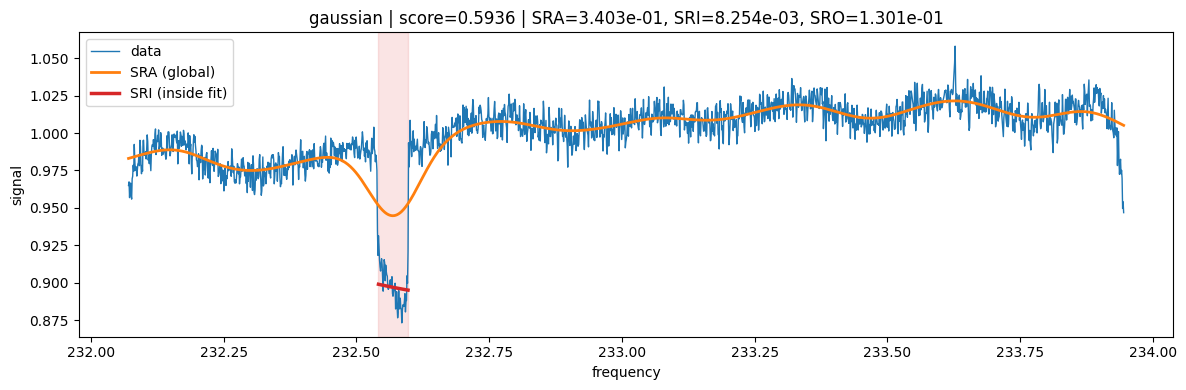

In [35]:
# Optional visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, out["pred_all"], color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit
inside = out["inside_idxs"]
plt.plot(
    freq_array[inside],
    out["pred_in"][inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if out.get("pred_out") is not None:
#     outside = out["outside_idxs"]
#     plt.plot(
#         y[outside],
#         out["pred_out"][outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"{out['kernel_kind']} | score={out['score']:.4f} | "
    f"SRA={out['sra']:.3e}, SRI={out['sri']:.3e}, SRO={out['sro']:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()



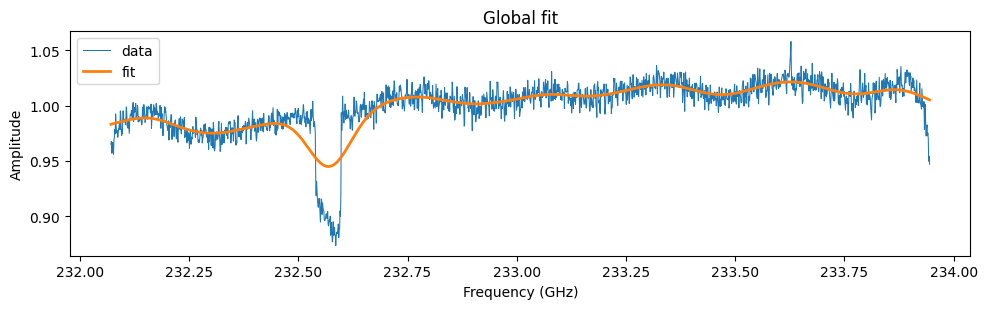

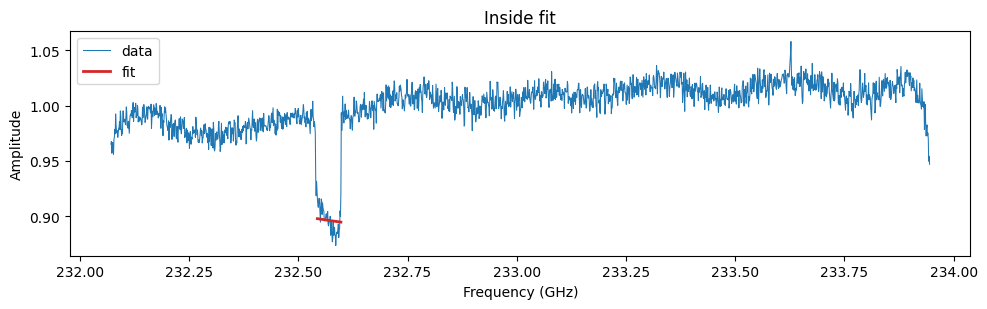

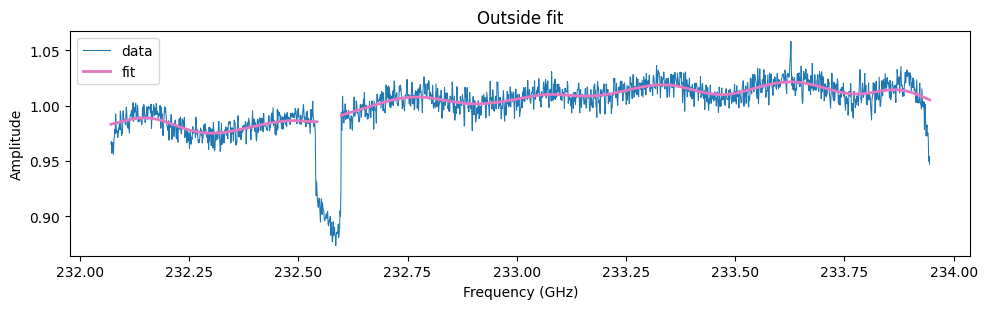

In [26]:
import matplotlib.pyplot as plt
import numpy as np

inside  = out["inside_idxs"]
outside = out["outside_idxs"]
full    = np.arange(len(x))

def scatter_with_gaps(ax, freq, signal, idxs, **kwargs):
    """Plot only the points at idxs, breaking the line at non-contiguous gaps."""
    # Build a full-length NaN array and fill only the selected indices
    y_plot = np.full(len(signal), np.nan)
    y_plot[idxs] = signal[idxs]
    ax.plot(freq, y_plot, **kwargs)

sections = [
    ("Global fit",  full,    full,    out["pred_all"], "C1"),
    ("Inside fit",  full,    inside,  out["pred_in"],  "C3"),
    ("Outside fit", full,    outside, out["pred_out"], "C76"),
]

for title, data_idxs, fit_idxs, pred, fit_color in sections:
    fig, ax = plt.subplots(figsize=(10, 3.2))
    # data is always the full spectrum
    ax.plot(freq_array[data_idxs], x[data_idxs], lw=0.75, color="#1f77b4", label="data")
    # fit only where it's defined, with NaN gaps breaking the line
    scatter_with_gaps(ax, freq_array, pred, fit_idxs, lw=2.0, color=fit_color, label="fit")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Amplitude")
    ax.set_title(title)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

## Alternative regressors (mean, polynomial, KRR)

The cells below score the same window using the `regressors` module, which mirrors the benchmark path in `benchmark_regressor_on_syth.py`. Each block:
1. Builds the global SRA with `regressors.build_regressor_sra`
2. Predicts on `inside` / `outside` index sets
3. Computes SRI, SRO and the normalized score
4. Plots the result

Note: `sro` is set to 0 here (score = 1 - sri/sra) because the benchmark path does not separate inside/outside SSE the same way the NWKR path does.

In [36]:
# Shared setup — re-derive inside/outside from the same ranges used above
n = x.size
inside  = make_inside_idxs(inside_ranges, n)
outside = complement_idxs(inside, n)

### Mean regressor

In [38]:
sra, ssr_all, pred_all, K_all, alpha_all, ssr_ps_all, mean_precompute = regressors.build_regressor_sra(
    x,
    family="mean",
    degree=1
)

In [39]:
pred_in_vals = regressors.predict_on_idxs_mean(
    x,
    inside
)

pred_in = np.full_like(x, np.nan, dtype=np.float64)
pred_in[inside] = pred_in_vals

resid_in = x[inside] - pred_in_vals
sri = float(np.sum(resid_in ** 2))


In [40]:
pred_out = None
sro = 0.0

if outside.size:
    pred_out_vals = regressors.predict_on_idxs_mean(
        x,
        outside
    )

    pred_out = np.full_like(x, np.nan, dtype=np.float64)
    pred_out[outside] = pred_out_vals

    resid_out = x[outside] - pred_out_vals
    sro = float(np.sum(resid_out ** 2))


In [41]:
eps = 1e-12
score = 1.0 - (sri / max(sra, eps))

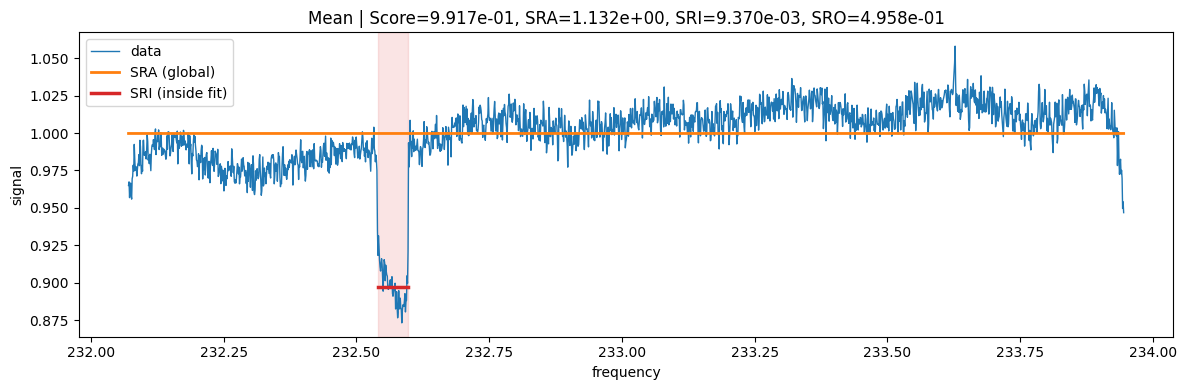

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, pred_all, color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit (SRI)
plt.plot(
    freq_array[inside],
    pred_in[inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if pred_out is not None:
#     plt.plot(
#         y[outside],
#         pred_out[outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"Mean | "
    f"Score={score:.3e}, SRA={sra:.3e}, SRI={sri:.3e}, SRO={sro:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


### Polynomial regressor (degree 5)

In [47]:
sra, ssr_all, pred_all, K_all, alpha_all, ssr_ps_all, mean_precompute = regressors.build_regressor_sra(
    x,
    family="poly",
    degree=2
)

In [48]:
pred_in_vals = regressors.predict_on_idxs_poly(
    x,
    inside,
    degree=5
)

pred_in = np.full_like(x, np.nan, dtype=np.float64)
pred_in[inside] = pred_in_vals

resid_in = x[inside] - pred_in_vals
sri = float(np.sum(resid_in ** 2))


In [49]:
pred_out = None
sro = 0.0

if outside.size:
    pred_out_vals = regressors.predict_on_idxs_poly(
        x,
        outside,
        degree=5
    )

    pred_out = np.full_like(x, np.nan, dtype=np.float64)
    pred_out[outside] = pred_out_vals

    resid_out = x[outside] - pred_out_vals
    sro = float(np.sum(resid_out ** 2))


In [50]:
eps = 1e-12
score = 1.0 - (sri / max(sra, eps))

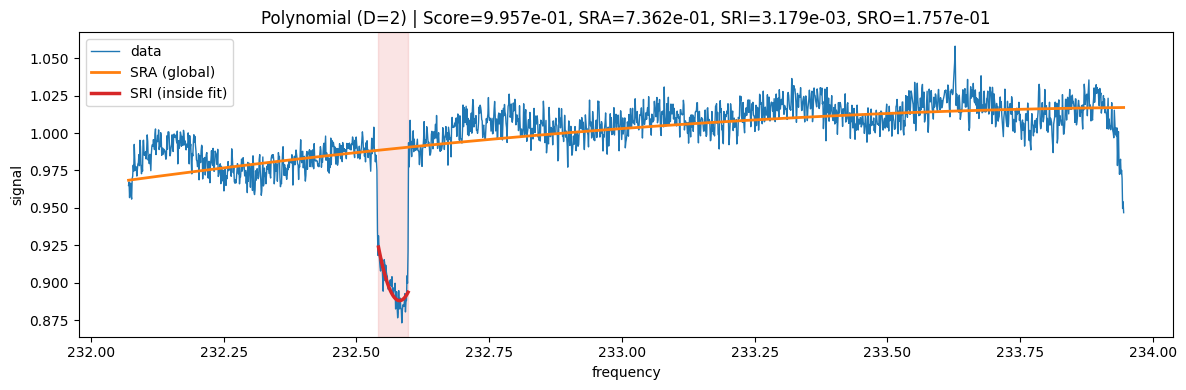

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, pred_all, color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit (SRI)
plt.plot(
    freq_array[inside],
    pred_in[inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if pred_out is not None:
#     plt.plot(
#         y[outside],
#         pred_out[outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"Polynomial (D=2) | "
    f"Score={score:.3e}, SRA={sra:.3e}, SRI={sri:.3e}, SRO={sro:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


### KRR regressor (Gaussian kernel)

In [54]:
sra, ssr_all, pred_all, K_all, alpha_all, ssr_ps_all, mean_precompute = regressors.build_regressor_sra(
    x,
    family="krr",
)

In [55]:
pred_in_vals = regressors.predict_on_idxs_krr(
    x,
    inside,
    kernel="gaussian"
)

pred_in = np.full_like(x, np.nan, dtype=np.float64)
pred_in[inside] = pred_in_vals

resid_in = x[inside] - pred_in_vals
sri = float(np.sum(resid_in ** 2))


In [56]:
pred_out = None
sro = 0.0

if outside.size:
    pred_out_vals = regressors.predict_on_idxs_krr(
        x,
        outside,
        kernel="gaussian"
    )

    pred_out = np.full_like(x, np.nan, dtype=np.float64)
    pred_out[outside] = pred_out_vals

    resid_out = x[outside] - pred_out_vals
    sro = float(np.sum(resid_out ** 2))


In [57]:
eps = 1e-12
score = 1.0 - (sri / max(sra, eps))

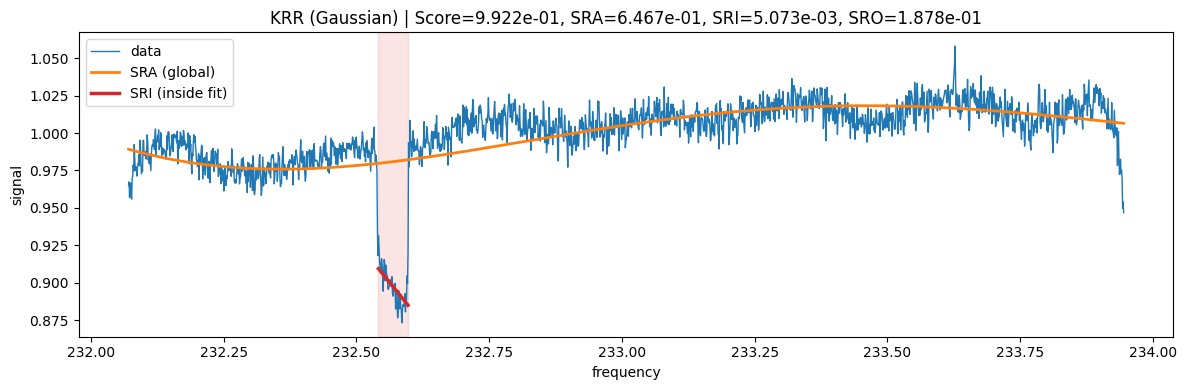

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Raw signal
plt.plot(freq_array, x, color="C0", linewidth=1.0, label="data")

# Global fit (SRA)
plt.plot(freq_array, pred_all, color="C1", linewidth=2.0, label="SRA (global)")

# Inside-only fit (SRI)
plt.plot(
    freq_array[inside],
    pred_in[inside],
    color="C3",
    linewidth=2.5,
    label="SRI (inside fit)",
)

# # Optional outside-only fit (SRO)
# if pred_out is not None:
#     plt.plot(
#         y[outside],
#         pred_out[outside],
#         color="C2",
#         linewidth=1.5,
#         linestyle="--",
#         label="SRO (outside fit)",
#     )

# Shade inside window
if inside.size:
    a, b = int(inside[0]), int(inside[-1])
    plt.axvspan(freq_array[a], freq_array[b], color="C3", alpha=0.12)

plt.title(
    f"KRR (Gaussian) | "
    f"Score={score:.3e}, SRA={sra:.3e}, SRI={sri:.3e}, SRO={sro:.3e}"
)
plt.xlabel("frequency")
plt.ylabel("signal")
plt.legend(loc="best")
plt.tight_layout()
plt.show()
